In [1]:
import MDAnalysis as mda
from MDAnalysis.transformations import unwrap, center_in_box
import os
import numpy as np
import freud
import matplotlib.pyplot as plt
import tqdm

In [2]:
lipids = 5000

In [3]:
def block_analysis(data, max_size = 10000):

    data = np.array(data)
    n = len(data)

    block_size = 10
    blocking_errors = []
    block_sizes = []

    while block_size <= min(max_size, n//2):

        n_blocks = n // block_size

        n_use = n_blocks * block_size
        data_trimmed = data[:n_use]

        blocks = data_trimmed.reshape(n_blocks, block_size)
        block_means = np.mean(blocks, axis=1)
        std_error = np.std(block_means, ddof=1) / np.sqrt(n_blocks)

        blocking_errors.append(std_error)
        block_sizes.append(block_size)

        block_size += 10

    plt.figure(figsize=(8, 5))
    plt.plot(block_sizes, blocking_errors, 'o-')
    plt.xlabel('Block Size')
    plt.ylabel('Standard Error')
    plt.grid(True)
    plt.title('Block Analysis')

    plt.show()
    
    return block_sizes, blocking_errors

In [4]:
def running_avg(lst):

    avg_lst = []
    std_lst = []

    for i in tqdm.tqdm(range(len(lst))):

       avg_lst.append(np.mean(lst[:i+1])) 
       std_lst.append(np.std(lst[:i+1]))

    return np.array(avg_lst), np.array(std_lst)

--------------------------------------------------------
Radius 10nm 16.17440225035162ru, werte 500001


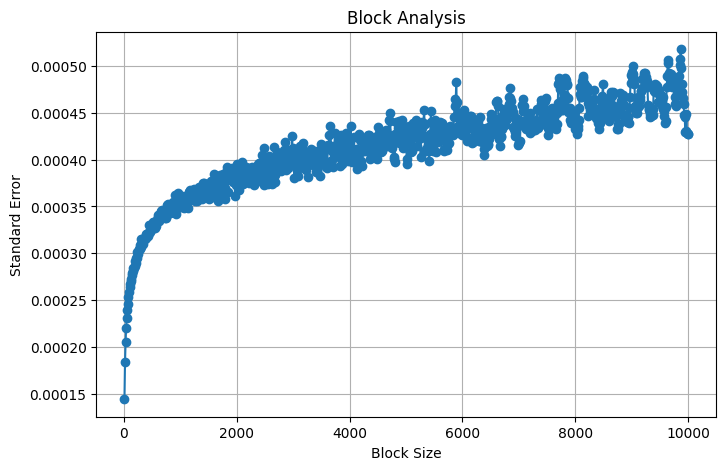

values for 10: -0.013436961939154968 +/- 0.04811421062353235
values on xx, yy: 0.00013436385094388052, -0.00013436385098547832
Force values: -30.966018051361477
Force per sigma: -26.0206112181216


100%|██████████| 500001/500001 [06:23<00:00, 1304.59it/s]




--------------------------------------------------------


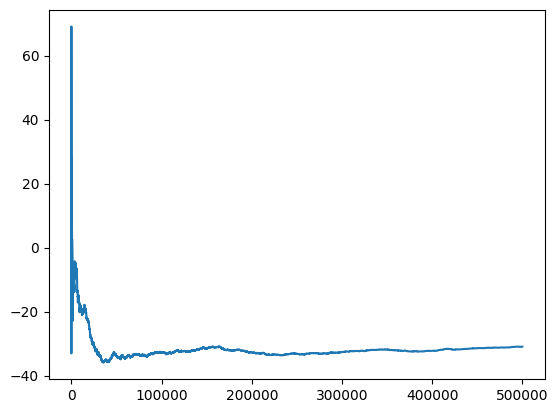

In [5]:
dir = "/home/gabriel/Dokumente/bachelor_thesis/dpd_simulation/bending_modulus/"

sigma_data = np.loadtxt(os.path.join(dir, f"tether_simulation/data/stress_and_force_10_differentapproach_big.dat"), skiprows=2, usecols=(1,2,3,4))

sigma_xx, sigma_yy, sigma_zz, force_z = sigma_data[:, 0], sigma_data[:, 1], sigma_data[:, 2], sigma_data[:, 3]

radius = 10/0.711 + 1.5/0.711


print("--------------------------------------------------------")
print(f"Radius {10}nm {radius}ru, werte {len(sigma_zz)}")

block_analysis(sigma_zz)

print(f"values for {10}: {(np.mean(sigma_zz))} +/- {np.std(sigma_zz)}")
print(f"values on xx, yy: {np.mean(sigma_xx)}, {np.mean(sigma_yy)}")
print(f"Force values: {np.mean(force_z)}")
print(f"Force per sigma: {np.mean(sigma_zz)*44.005626**2}")
a,b = running_avg(force_z)

plt.plot(a)
print("")
print("")
print("--------------------------------------------------------")

--------------------------------------------------------
Radius 10nm 16.17440225035162ru, werte 500001


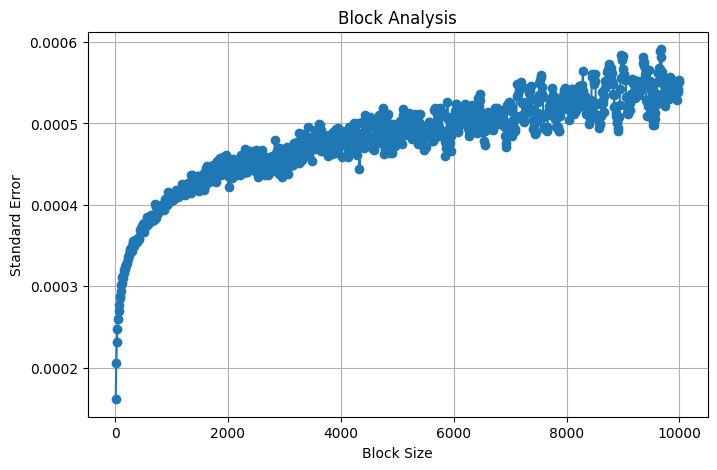

values for 10: -0.01749296029917376 +/- 0.05261121168722879
values on xx, yy: -2.478182467875443e-05, 2.4781824718774364e-05
Force values: -33.875032452160475
Force per sigma: -33.87503224761401


100%|██████████| 500001/500001 [05:59<00:00, 1391.92it/s]




--------------------------------------------------------


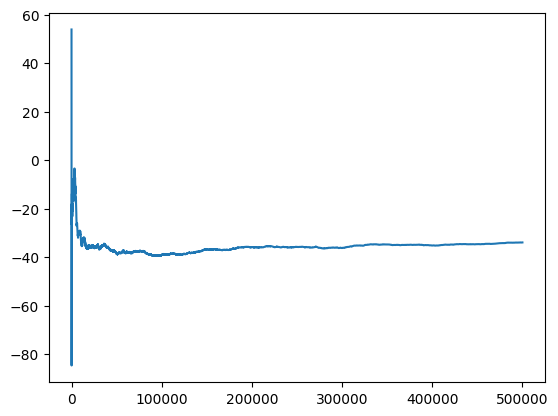

In [5]:
dir = "/home/gabriel/Dokumente/bachelor_thesis/dpd_simulation/bending_modulus/"

sigma_data = np.loadtxt(os.path.join(dir, f"tether_simulation/data/stress_and_force_10_differentapproach.dat"), skiprows=2, usecols=(1,2,3,4))

sigma_xx, sigma_yy, sigma_zz, force_z = sigma_data[:, 0], sigma_data[:, 1], sigma_data[:, 2], sigma_data[:, 3]

radius = 10/0.711 + 1.5/0.711


print("--------------------------------------------------------")
print(f"Radius {10}nm {radius}ru, werte {len(sigma_zz)}")

block_analysis(sigma_zz)

print(f"values for {10}: {(np.mean(sigma_zz))} +/- {np.std(sigma_zz)}")
print(f"values on xx, yy: {np.mean(sigma_xx)}, {np.mean(sigma_yy)}")
print(f"Force values: {np.mean(force_z)}")
print(f"Force per sigma: {np.mean(sigma_zz)*44.005626**2}")
a,b = running_avg(force_z)

plt.plot(a)
print("")
print("")
print("--------------------------------------------------------")

--------------------------------------------------------
Radius 10nm 16.17440225035162ru, werte 250001


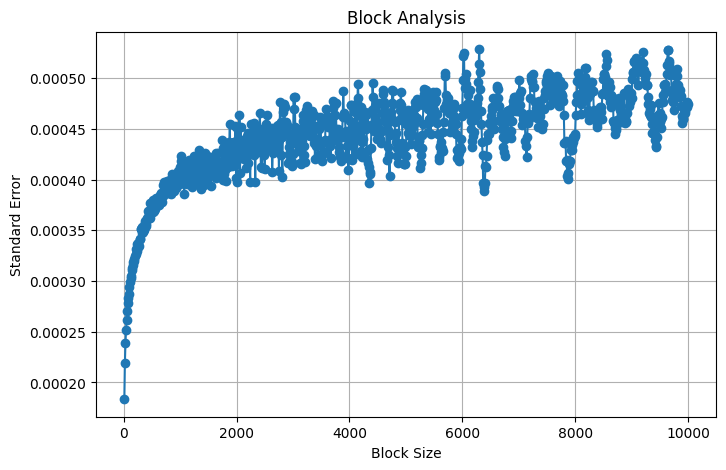

values for 10: -0.011173523318457078 +/- 0.040504424719137844
values on xx, yy: 1.4776500012931926e-05, -1.477650001297193e-05
Force values: -25.749832987160133
Force per sigma: -25.74983285463829


100%|██████████| 250001/250001 [00:52<00:00, 4726.84it/s]




--------------------------------------------------------


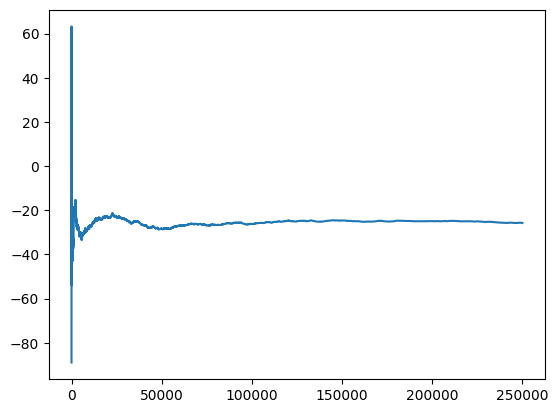

In [5]:
dir = "/home/gabriel/Dokumente/bachelor_thesis/dpd_simulation/bending_modulus/"

sigma_data = np.loadtxt(os.path.join(dir, f"tether_simulation/data/stress_and_force_10.dat"), skiprows=2, usecols=(1,2,3,4))

sigma_xx, sigma_yy, sigma_zz, force_z = sigma_data[:, 0], sigma_data[:, 1], sigma_data[:, 2], sigma_data[:, 3]

radius = 10/0.711 + 1.5/0.711


print("--------------------------------------------------------")
print(f"Radius {10}nm {radius}ru, werte {len(sigma_zz)}")

block_analysis(sigma_zz)

print(f"values for {10}: {(np.mean(sigma_zz))} +/- {np.std(sigma_zz)}")
print(f"values on xx, yy: {np.mean(sigma_xx)}, {np.mean(sigma_yy)}")
print(f"Force values: {np.mean(force_z)}")
print(f"Force per sigma: {np.mean(sigma_zz)*48.005626**2}")
a,b = running_avg(force_z)

plt.plot(a)
print("")
print("")
print("--------------------------------------------------------")

--------------------------------------------------------
Radius 10nm 16.17440225035162ru, werte 250001


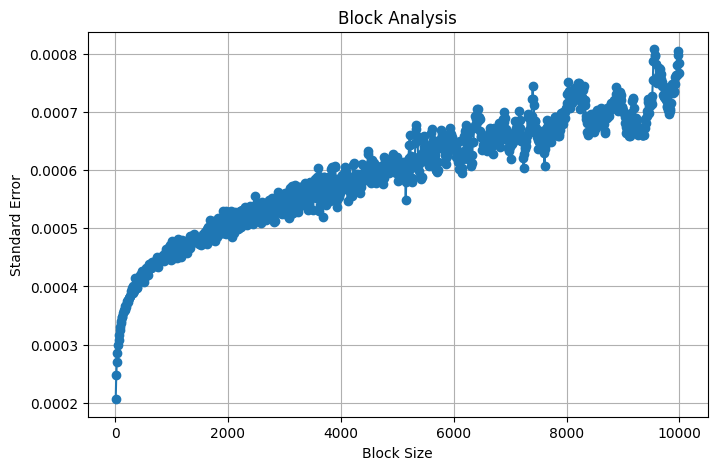

values for 10: -0.018312584006841923 +/- 0.044718430489521274
values on xx, yy: 0.0003053675604189531, -0.0003053675603757497
Force values: -35.46222963415402
Force per sigma: -35.46222936251732


100%|██████████| 250001/250001 [00:57<00:00, 4379.08it/s]




--------------------------------------------------------


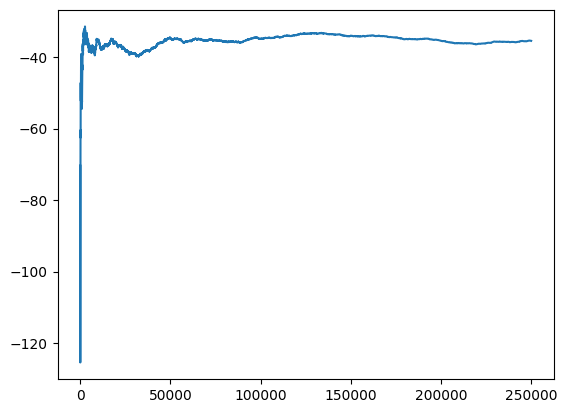

In [6]:
dir = "/home/gabriel/Dokumente/bachelor_thesis/dpd_simulation/bending_modulus/"

sigma_data = np.loadtxt(os.path.join(dir, f"tether_simulation/data/stress_and_force_10_smaller_box.dat"), skiprows=2, usecols=(1,2,3,4))

sigma_xx, sigma_yy, sigma_zz, force_z = sigma_data[:, 0], sigma_data[:, 1], sigma_data[:, 2], sigma_data[:, 3]

radius = 10/0.711 + 1.5/0.711


print("--------------------------------------------------------")
print(f"Radius {10}nm {radius}ru, werte {len(sigma_zz)}")

block_analysis(sigma_zz)

print(f"values for {10}: {(np.mean(sigma_zz))} +/- {np.std(sigma_zz)}")
print(f"values on xx, yy: {np.mean(sigma_xx)}, {np.mean(sigma_yy)}")
print(f"Force values: {np.mean(force_z)}")
print(f"Force per sigma: {np.mean(sigma_zz)*44.0056258790436**2}")
a,b = running_avg(force_z)

plt.plot(a)
print("")
print("")
print("--------------------------------------------------------")

--------------------------------------------------------
Radius 10nm 16.17440225035162ru, werte 1000001


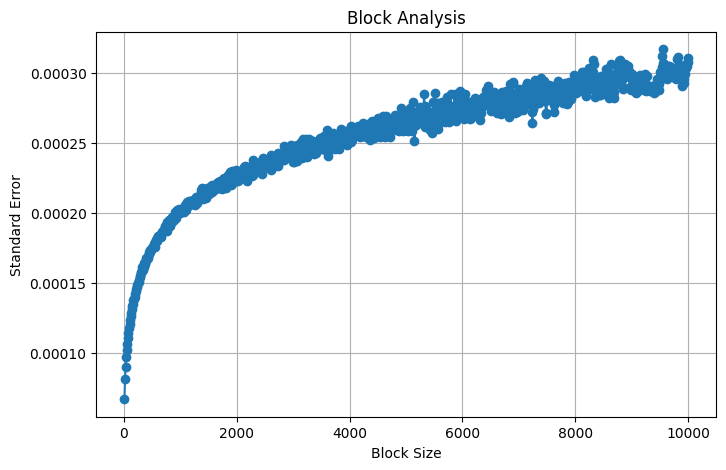

values for values_10_smaller_box: 0.011268812490820429 +/- 0.025170061674894915
values on xx, yy: -3.958739901945654e-05, 3.958739902944782e-05

Force: 11.792194206855912
kappa: 30.355891668197476

--------------------------------------------------------
--------------------------------------------------------
Radius 10nm 16.17440225035162ru, werte 250001


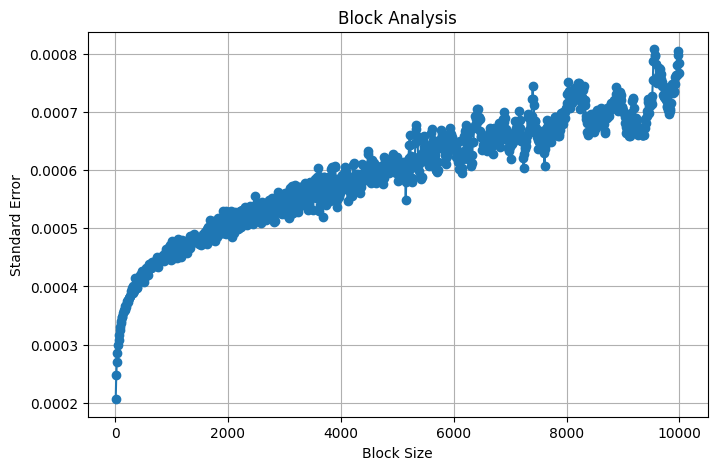

values for and_force_10_smaller_box: -0.018312584006841923 +/- 0.044718430489521274
values on xx, yy: 0.0003053675604189531, -0.0003053675603757497

Force: -19.163114765992667
kappa: -49.3303812384216

--------------------------------------------------------


In [13]:
dir = "/home/gabriel/Dokumente/bachelor_thesis/dpd_simulation/bending_modulus/"

R = ["values_10_smaller_box", "and_force_10_smaller_box"]
R_int = [10,10]
box = [48.0056258790436**2, 44.0056258790436**2]

F = []

for (Rad,R_int,area) in zip(R,R_int,box):

    sigma_data = np.loadtxt(os.path.join(dir, f"tether_simulation/data/stress_{Rad}.dat"), skiprows=2, usecols=(1,2,3))

    sigma_xx, sigma_yy, sigma_zz = sigma_data[:, 0], sigma_data[:, 1], sigma_data[:, 2]

    radius = R_int/0.711 + 1.5/0.711

    
    print("--------------------------------------------------------")
    print(f"Radius {R_int}nm {radius}ru, werte {len(sigma_zz)}")

    block_analysis(sigma_zz)

    print(f"values for {Rad}: {(np.mean(sigma_zz))} +/- {np.std(sigma_zz)}")
    print(f"values on xx, yy: {np.mean(sigma_xx)}, {np.mean(sigma_yy)}")
    print("")
    print(f"Force: {np.mean(sigma_zz)*4*radius**2}")
    print(f"kappa: {np.mean(sigma_zz)*4*radius**2*radius/(2*np.pi)}")
    print("")
    print("--------------------------------------------------------")

    F.append(np.mean(sigma_zz)*area)

In [18]:
def calc_bend(top_file, traj_file, sigma_file):

    u = mda.Universe(top_file, format="DATA", atom_style="id resid type charge x y z")
    u.load_new(traj_file, format="LAMMPSDUMP", dt=1.0)

    print(len(u.trajectory))

    lipid_atoms = u.select_atoms(f"resid 1:{lipids}")
    heads = u.select_atoms(f"resid 1:{lipids} and type 5")


    sigma_data = np.loadtxt(sigma_file, skiprows=2, usecols=(1,2,3))

    sigma_xx, sigma_yy, sigma_zz = sigma_data[:, 0], sigma_data[:, 1], sigma_data[:, 2]

    for sig in [sigma_xx, sigma_yy, sigma_zz]:

        plt.plot(running_avg(sig)[0])
        #plt.plot(sig, alpha = 0.2)
    plt.ylim((-0.02, 0.02))
    plt.show()

    box_dims = u.dimensions[:3]
    F_z = np.mean(sigma_zz)*box_dims[0]*box_dims[1]

    print(f"Force F_z = {F_z}")

    Radii = []

    for ts in u.trajectory:
        
        center = lipid_atoms.center_of_mass()
        _, _, cylinder_axis = lipid_atoms.principal_axes()
        cylinder_axis = np.array([0,0,1])

        positions = heads.positions - center
        proj_on_axis = (positions @ cylinder_axis).reshape(-1, 1)*cylinder_axis
        radial_dist = np.linalg.norm(positions - proj_on_axis, axis=1)

        R_inner = np.percentile(radial_dist, 5)
        R_outer = np.percentile(radial_dist, 95)

        R = (R_inner + R_outer)/2

        Radii.append(R)

    R = np.mean(Radii)

    plt.plot(Radii)
    plt.show()
    print(f"Final radius R={R}")

    print(f"bending modulus kappa = {F_z*R/(2*np.pi)}")



101


100%|██████████| 1001/1001 [00:00<00:00, 61697.26it/s]


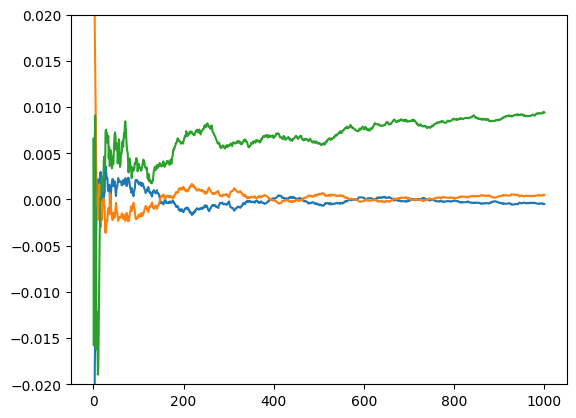

Force F_z = 12.741782678191992


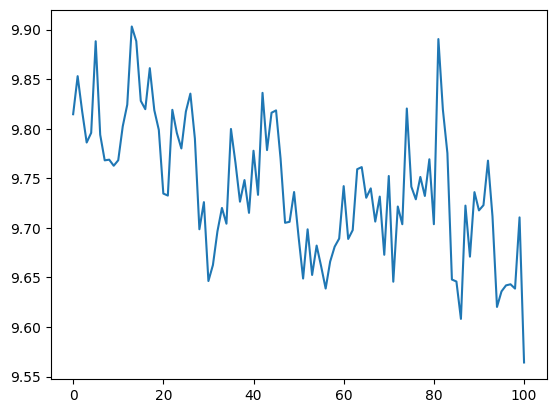

Final radius R=9.741118239720903
bending modulus kappa = 19.754186067259386
101


100%|██████████| 1001/1001 [00:00<00:00, 49762.93it/s]


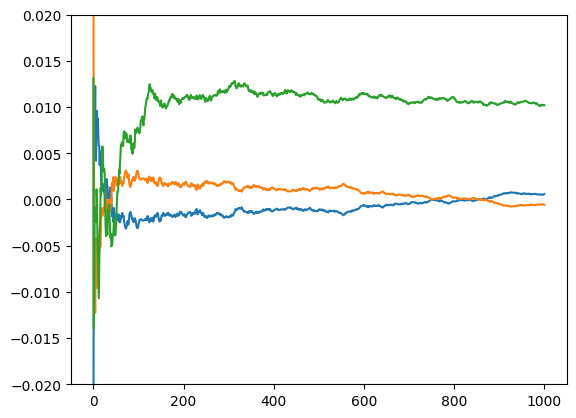

Force F_z = 18.329637166481067


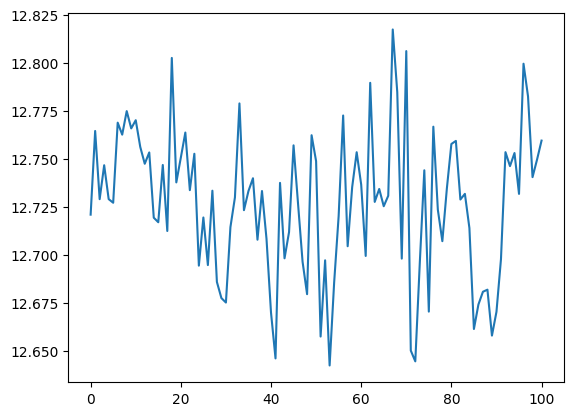

Final radius R=12.726970904492614
bending modulus kappa = 37.1277859083909


In [19]:
dir = "/home/gabriel/Dokumente/bachelor_thesis/dpd_simulation/bending_modulus/"

Radii = ["6", "8"]

for R in Radii:

    top_file = os.path.join(dir, f"setup/cylinder_{R}.data")
    traj_file = os.path.join(dir, f"tether_simulation/data/cylinder_sim_{R}.lammpstrj")
    sigma_file = os.path.join(dir, f"tether_simulation/data/stress_values_{R}.dat")

    calc_bend(top_file, traj_file, sigma_file)

In [43]:
u = mda.Universe(os.path.join(dir, "setup/cylinder.data"), format="DATA", atom_style = "id resid type charge x y z")
u.load_new(os.path.join(dir,"tether_simulation/cylinder_sim.lammpstrj"), format="LAMMPSDUMP", dt=0.01)

<Universe with 269386 atoms>

In [54]:
for ts in u.trajectory[:10]:
    lipids_atoms = u.select_atoms(f"resid 1:{lipids}")

    axes = lipids_atoms.principal_axes()

    print(axes[2])

[-0.01760518  0.01438405 -0.99974154]
[ 0.01648205 -0.01517737  0.99974896]
[-0.01963074  0.0120628  -0.99973453]
[ 0.01144182 -0.00464312  0.99992376]
[-3.71598873e-04  8.63110283e-03 -9.99962682e-01]
[-0.01398644 -0.00858877  0.9998653 ]
[ 0.00897544  0.00101469 -0.99995921]
[-0.003423    0.0138695  -0.99989795]
[ 0.00463912 -0.02450703  0.99968889]
[ 0.00422715  0.01511004 -0.9998769 ]


In [25]:
forces = [  8.8932716   ,
 -51.561885   ,
  65.127656   ,
  10.93271    ,
  27.964705   ,
 -73.471805   ,
 -62.386134   ,
 -100.71506   ,
  26.997833   ,
 -57.225619   ,
 -76.213106   ,
 -6.9864893   ,
  52.568039   ,
  81.506316   ,
  78.443152   ,
  42.12289    ,
  39.357458   ,
 -7.1972856   ,
  43.379048   ,
  25.3677     ,
 -10.144155   ,
 -26.058983   ,
  20.952814   ,
  80.191359   ,
  24.933373   ,
 -11.602705   ,
 -14.375133   ,
  147.82185   ,
  17.508168   ,
 -25.361124   ,
  30.271      ,
 -33.996723   ,
  20.511647   ,
  29.053055   ,
 -106.51899   ,
  65.502093   ,
 -94.499663   ,
  10.618444   ,
  88.939311   ,
 -7.2262808   ,
 -25.161545   ,
 -57.107475   ,
  27.510708   ,
  56.027314   ,
 -42.721097   ,
  58.876986   ,
  94.901414   ,
  64.782508   ,
  29.992139   ,
 -20.26379    ,
 -87.573389   ,
  54.872252   ,
 -24.635675   ,
  0.40977059  ,
 -113.1613    ,
  76.655992   ,
  118.48893   ,
  24.621218   ,
 -116.75343   ,
 -107.86073   ,
  24.320739   ,
  76.399593   ,
  31.970147   ,
  24.080643   ,
  96.861245   ,
  23.21885    ,
 -48.204574   ,
  87.377157   ,
  69.149608   ,
 -34.816925   ,
  165.32453   ,
  21.464488   ,
 -81.591935   ,
 -82.174256   ,
 -78.166535   ,
 -39.838177   ,
 -9.5368188   ,
 -102.01655   ,
 -117.56273   ,
  100.66282   ,
  74.19043    ,
 -28.818418   ,
 -55.38827    ,
  5.8396068   ,
 -57.760049   ,
 -81.187317   ,
  84.832294   ,
  58.221498   ,
 -38.688538   ,
  27.177743   ,
 -5.2162436   ,
  34.25617    ,
  68.135395   ,
 -9.3815928   ,
  23.252834   ,
  69.111307   ,
 -7.0890506   ,
 -8.6838838   ,
 -155.86746   ,
  46.13079    ,
  53.385705   ,
  19.745282   ,
 -56.465104   ,
  0.97878724  ,
  4.7473886   ,
  15.306438   ,
 -43.045969   ,
  32.634742   ,
  47.049783   ,
  21.98902    ,
  75.471411   ,
  25.704126   ,
 -20.34895    ,
 -2.674229    ,
 -71.923668   ,
 -15.395334   ,
  3.8670695   ,
 -17.007458   ,
  29.57439    ,
 -51.349627   ,
 -127.04893   ,
  14.946444   ,
 -42.823956   ,
  105.34254   ,
 -128.74212   ,
  21.585005   ,
 -10.727282   ,
  14.35842    ,
 -50.029306   ,
  36.516383   ,
 -23.011188   ,
  33.165996   ,
  21.021881   ,
  97.235205   ,
  95.612263   ,
  22.549679   ,
  66.37432    ,
  2.5398148   ,
 -58.900408   ,
  9.8304739   ,
  67.140486   ,
  38.667656   ,
  3.4600604   ,
 -50.692403   ,
  57.694025   ,
 -21.001213   ,
  31.173504   ,
  57.943423   ,
 -34.812417   ,
 -8.5041747   ,
  10.842036   ,
 -25.725681   ,
  9.5754886   ,
  55.760933   ,
 -18.504405   ,
  89.919342   ,
 -28.70233    ,
 -29.391699   ,
 -53.272703   ,
  71.626057   ,
 -15.952081   ,
  28.413398   ,
  11.92793    ,
  63.327879   ,
 -18.801303   ,
  38.347175   ,
 -38.116765   ,
  15.671539   ,
 -26.7049     ,
 -28.577484   ,
  79.942411   ,
  61.191935   ,
 -1.3974804   ,
 -92.070534   ,
  109.30902   ,
  83.070555   ,
  40.718377   ,
  148.777     ,
  5.6233619   ,
  56.561218   ,
  4.2086513   ,
  58.001059   ,
  35.220139   ,
  73.165374   ,
  2.4706901   ,
  31.127263   ,
  57.658564   ,
  69.348099   ,
 -64.265325   ,
  6.7173134   ,
  30.477785   ,
 -18.055048   ,
 -1.6404413   ,
 -23.515629   ,
 -22.279131   ,
  22.914806   ,
  29.866755   ,
  15.930778   ,
  15.963582   ,
 -42.212064   ,
  80.182208   ,
  59.80286    ,
  74.100187   ,
  39.629164   ,
 -9.5888215   ,
  68.379406   ,
  123.5671    ,
 -58.537289   ,
 -56.032635   ,
 -9.2066346   ,
  50.275485   ,
  21.002677   ,
  11.881446   ,
  82.754602   ,
  15.1497     ,
 -37.897628   ,
  71.833077   ,
 -12.361486   ,
  14.327424   ,
 -4.4828199   ,
 -41.193682   ,
  9.9725751   ,
 -12.252251   ,
 -10.7129     ,
  13.498775   ,
  68.303355   ,
  24.744997   ,
  79.890335   ,
  7.0141778   ,
  0.22553146  ,
  59.889837   ,
 -26.118366   ,
 -49.22507    ,
  44.919526   ,
  45.642427   ,
  39.044429   ,
 -35.824696   ,
 -77.042513   ,
 -24.116089   ,
  93.940185   ,
  31.175191   ,
  30.494255   ,
  43.068427   ,
  39.59384    ,
  1.0338801   ,
  47.198099   ,
  95.025341   ,
 -17.287019   ,
  73.530716   ,
 -75.125197   ,
  47.424888   ,
  77.477902   ,
 -24.210944   ,
  89.271868   ,
 -47.372687   ,
 -27.963737   ,
  16.433914   ,
 -45.466424   ,
  28.356369   ,
 -66.6938     ,
  46.294397   ,
  66.748985   ,
  49.913648   ,
 -24.473633   ,
 -175.50256   ,
 -36.736216   ,
 -1.8730031   ,
 -42.183147   ,
 -29.519476   ,
 -6.9767667   ,
 -41.621234   ,
 -34.371402   ,
 -53.040617   ,
 -32.203509   ,
 -2.5177688   ,
 -77.685855   ,
 -25.151228   ,
  39.045358   ,
  8.2886948   ,
  14.414603   ,
 -108.12988   ,
 -43.992673   ,
  11.625384   ,
 -55.40647    ,
  69.73775    ,
  5.7126674   ,
  18.756183   ,
  56.237646   ,
 -58.724466   ,
  19.874621   ,
  7.4372591   ,
 -66.088065   ,
  2.0256454   ,
  57.742631   ,
  72.728943   ,
  13.962346   ,
 -45.587537   ,
  91.003375   ,
 -62.347451   ,
  33.00119    ,
  23.055645   ,
 -8.5077158   ,
  50.883015   ,
  10.843112   ,
  59.04181    ,
  31.166132   ,
 -69.765832   ,
 -21.812734   ,
 -3.72844     ,
  107.4956    ,
  64.557039   ,
  22.590537   ,
 -36.076413   ,
  26.116445   ,
 -13.20728    ,
 -5.0888135   ,
  53.201157   ,
  2.6808681   ,
  33.235702   ,
  51.784821   ,
 -63.546271   ,
  80.329699   ,
  5.1727313   ,
  15.14244    ,
 -7.7853643   ,
 -81.398099   ,
  53.195057   ,
 -44.270242   ,
 -21.478945   ,
  10.102394   ,
  28.480261   ,
  92.202133   ,
 -8.1423635   ,
  73.474693   ,
  64.742674   ,
 -32.95953    ,
  75.6786     ,
 -39.920069   ,
  21.768686   ,
 -82.725697   ,
  16.70895    ,
 -17.229987   ,
 -85.93103    ,
 -84.358115   ,
 -49.810111   ,
 -3.0368206   ,
  73.304325   ,
  5.1679354   ,
  25.23232    ,
  60.753762   ,
  100.66129   ,
  1.5857784   ,
  18.644905   ,
 -36.235425   ,
  128.23439   ,
 -44.31356    ,
  39.573808   ,
  26.840208   ,
 -48.522688   ,
  1.230146    ,
  117.54393   ,
 -48.035888   ,
  98.376728   ,
 -16.426242   ,
 -26.833677   ,
  24.669278   ,
 -26.937386   ,
  56.841677   ,
 -12.845072   ,
 -61.307443   ,
  0.28117063  ,
  53.9321     ,
  119.98506   ,
  51.417531   ,
 -14.399223   ,
  96.55087    ,
  52.380586   ,
  49.142367   ,
 -21.853294   ,
  51.606779   ,
 -40.07093    ,
  50.461575   ,
  40.161209   ,
 -29.062931   ,
  64.601649   ,
  23.187196   ,
 -122.52284   ,
 -11.546139   ,
  90.086593   ,
  40.132811   ,
  30.320264   ,
 -92.123076   ,
  34.527594   ,
  57.228662   ,
 -5.6467505   ,
 -17.680042   ,
  15.69725    ,
 -11.525804   ,
  89.053093   ,
 -62.402758   ,
 -80.040284   ,
  96.927973   ,
 -6.0482935   ,
  35.123702   ,
  35.321724   ,
  137.64298   ,
 -5.1821277   ,
  32.086173   ,
 -2.3982295   ,
  35.201988   ,
  23.494192   ,
 -14.88651    ,
 -74.215207   ,
 -50.326681   ,
 -72.957248   ,
  21.890462   ,
  17.666611   ,
 -4.9853452   ,
 -20.350019   ,
 -61.366676   ,
  5.5851784   ,
  10.893316   ,
  193.31141   ,
 -33.531861   ,
  1.9162505   ,
 -113.78715   ,
 -60.382158   ,
  32.087763   ,
  42.05958    ,
  53.933107   ,
  17.73729    ,
  44.941577   ,
 -12.981761   ,
  46.250163   ,
 -78.065956   ,
  18.989414   ,
 -107.95773   ,
  21.932944   ,
  7.1391092   ,
  67.547162   ,
 -51.446127   ,
 -41.115852   ,
  73.727327   ,
  79.425045   ,
  18.970677   ,
  45.571176   ,
  15.16084    ,
  51.42612    ,
  67.531776   ,
 -14.560616   ,
  65.917298   ,
 -79.17157    ,
  5.187164    ,
 -42.881502   ,
 -44.604056   ,
  39.73744    ,
  83.693818   ,
  20.41234    ,
  77.611271   ,
  26.680888   ,
 -41.932361   ,
  40.888006   ,
 -71.141771   ,
 -116.69701   ,
 -15.367622   ,
 -4.2344086   ,
 -24.647432   ,
  86.312484   ,
 -44.852205   ,
  41.785889   ,
  38.025969   ,
 -20.463063   ,
  38.927157   ,
 -2.9537958   ,
 -16.658      ,
  4.4545497   ,
 -39.561862   ,
 -53.514232   ,
  114.22129   ,
 -13.996439   ,
  16.744307   ,
  89.779015   ,
 -93.504804   ,
 -47.32963    ,
 -23.441479   ,
 -36.079104   ,
 -24.521418   ,
  20.374447   ,
  92.983851   ,
  5.8310487   ,
 -82.619051   ,
  34.202853   ,
 -36.791901   ,
  71.144526   ,
  45.946174   ,
 -2.7569624   ,
 -77.85204    ,
 -48.307525   ,
  10.775617   ,
  54.119128   ,
 -34.704045   ,
 -13.563135   ,
  30.113659   ,
 -3.9331396   ,
 -34.125054   ,
 -68.247073   ,
  24.153645   ,
  46.02949    ,
  29.605231   ,
  19.005809   ,
  72.479387   ,
 -109.89915   ,
  26.345686   ,
  79.168028   ,
 -17.220558   ,
  99.73094    ,
  96.698243   ,
  8.987068    ,
 -12.365213   ,
  149.23561   ,
  25.062171   ,
  20.56049    ,
  55.84025    ,
  35.023858   ,
  41.362072   ,
 -44.107309   ,
 -83.528225   ,
  36.981177   ,
  77.969558   ,
 -5.2072814   ,
  81.272513   ,
 -12.549287   ,
  40.624531   ,
 -6.3534471   ,
  125.54471   ,
  60.041129   ,
 -29.783162   ,
  40.566495   ,
  118.1171    ,
 -31.492943   ,
 -9.8468877   ,
  101.64332   ,
  32.332378   ,
  31.748745   ,
  51.148376   ,
  66.114417   ,
 -6.029136    ,
  112.8468    ,
 -40.435867   ,
 -79.944597   ,
  163.39493   ,
 -99.069304   ,
  66.755393   ,
  77.52312    ,
  77.062908   ,
  36.171016   ,
  35.925038   ,
  100.15415   ,
  30.824339   ,
  9.0194419   ,
 -20.172355   ,
  94.27208    ,
  97.17564    ,
 -84.173625   ,
 -20.000745   ,
 -6.7965427   ,
  63.769465   ,
  56.988906   ,
 -10.490167   ,
  64.553879   ,
  158.00797   ,
 -34.719247   ,
 -119.89599   ,
 -1.3890707   ,
 -51.436428   ,
  39.869152   ,
 -56.259056   ,
  12.215911   ,
 -35.948018   ,
 -1.1753834   ,
 -52.687939   ,
  21.312418   ,
 -41.411273   ,
 -32.126768   ,
  4.6657025   ,
 -3.0219315   ,
 -28.202916   ,
  39.422871   ,
  28.392694   ,
  16.906369   ,
  180.24157   ,
  44.049034   ,
 -11.955478   ,
 -78.435121   ,
  70.773617   ,
  45.495321   ,
  93.476935   ,
  104.9659    ,
 -43.473132   ,
 -109.54885   ,
 -61.479178   ,
  14.914388   ,
  108.45885   ,
  123.0222    ,
 -0.79103311  ,
 -126.11978   ,
 -68.341655   ,
 -57.480571   ,
  56.427592   ,
  91.275935   ,
 -129.33839   ,
  40.082484   ,
 -15.227564   ,
 -24.927557   ,
  140.11725   ,
  84.679607   ,
  25.472589   ,
 -57.319986   ,
  83.363743   ,
  7.7940794   ,
    138.12318  ,
  61.532945  ,
  92.024498  ,
  131.9305   ,
  74.596147  ,
  17.396087  ,
 -38.626878  ,
 -19.334319  ,
  4.3594206  ,
  10.772857  ,
  8.551351   ,
 -2.6151332  ,
  30.017808  ,
 -11.740535  ,
 -51.867896  ,
  15.109802  ,
 -24.441308  ,
  25.679389  ,
 -43.015753  ,
  1.695172   ,
  14.917908  ,
  34.802713  ,
  19.632272  ,
  40.761005  ,
 -4.3897548  ,
  12.277504  ,
  68.709722  ,
 -7.2698677  ,
  114.43758  ,
  87.209982  ,
  59.995016  ,
  15.109477  ,
  78.734586  ,
 -89.829955  ,
 -56.381558  ,
 -62.609399  ,
 -24.640837  ,
  66.726416  ,
  68.93246   ,
  11.645126  ,
 -24.31533   ,
  77.781286  ,
  59.874796  ,
  85.132412  ,
  66.654054  ,
  95.269906  ,
  45.000434  ,
  83.212341  ,
 -23.803621  ,
 -34.179021  ,
 -115.40886  ,
 -16.251401  ,
  5.5195563  ,
  0.11489866 ,
  49.633593  ,
  91.306803  ,
 -40.708415  ,
  108.0889   ,
 -64.098736  ,
  59.456532  ,
  30.722339  ,
  25.865272  ,
  119.12392  ,
 -52.837764  ,
 -40.131281  ,
  34.441575  ,
  6.5033803  ,
 -49.525086  ,
  14.963755  ,
  65.484707  ,
  59.915681  ,
 -136.32147  ,
  48.173952  ,
  58.188313  ,
  74.304045  ,
 -89.107732  ,
 -86.831805  ,
  86.172624  ,
  3.7172155  ,
 -10.075903  ,
  21.590819  ,
 -2.9526484  ,
  33.848957  ,
 -6.885472   ,
  66.714325  ,
 -12.375986  ,
  57.883378  ,
 -21.914733  ,
  143.81883  ,
 -18.525315  ,
 -103.01088  ,
  56.662681  ,
  48.431165  ,
 -81.555908  ,
  1.1512826  ,
 -84.67077   ,
 -60.077344  ,
 -72.183584  ,
  34.940847  ,
 -120.0734   ,
 -2.9267089  ,
 -81.425811  ,
  104.31685  ,
 -58.13635   ,
  19.034546  ,
  19.528641  ,
  116.19435  ,
 -133.53903  ,
 -49.508733  ,
  7.3764141  ,
  0.37208313 ,
  2.17938    ,
  66.362361  ,
 -34.173881  ,
 -12.266125  ,
  63.287107  ,
  19.043732  ,
  6.59846    ,
 -82.075855  ,
 -113.09613  ,
  26.809312  ,
  49.536388  ,
 -1.3791863  ,
  73.41256   ,
 -18.841652  ,
  4.3927025  ,
  52.236633  ,
 -83.839771  ,
  40.316556  ,
  76.694571  ,
  36.69507   ,
  135.96529  ,
 -79.02015   ,
  84.081075  ,
  21.854085  ,
  53.193606  ,
  135.27319  ,
  11.903683  ,
  31.641553  ,
  33.545934  ,
  36.958364  ,
  42.746794  ,
  106.61454  ,
 -34.542609  ,
  10.652792  ,
 -10.868495  ,
  31.471252  ,
  88.777939  ,
  10.043141  ,
  33.376124  ,
 -14.162644  ,
 -20.171446  ,
  167.80903  ,
  15.520335  ,
 -32.851141  ,
 -18.570551  ,
  32.025808  ,
 -56.329134  ,
 -30.602686  ,
 -25.768833  ,
 -35.066722  ,
  59.556298  ,
  32.765662  ,
  34.890697  ,
  82.017689  ,
  83.798907  ,
  75.360962  ,
 -84.776355  ,
  51.976516  ,
 -24.64939   ,
 -14.022016  ,
  85.659273  ,
  10.677353  ,
  40.456878  ,
  50.583315  ,
  16.155885  ,
  82.425491  ,
  16.554328  ,
  95.486946  ,
  40.53418   ,
 -89.513583  ,
  32.878723  ,
  18.580779  ,
 -19.619514  ,
  18.924441  ,
 -27.159823  ,
  116.19991  ,
 -79.769312  ,
  64.455597  ,
 -4.9168553  ,
  15.011881  ,
  64.508077  ,
  52.516967  ,
  22.108393  ,
 -40.997423  ,
  86.846763  ,
 -0.75023464 ,
 -35.418293  ,
  32.675545  ,
 -13.12393   ,
 -18.62315   ,
  22.291084  ,
  81.417561  ,
  26.204967  ,
  14.091546  ,
  49.292001  ,
  34.684255  ,
 -24.18135   ,
  17.655337  ,
 -7.4286898  ,
  24.272107  ,
  27.753249  ,
  32.773597  ,
 -44.311924  ,
  51.69382   ,
  0.43350244 ,
  60.001139  ,
  99.038158  ,
  6.5600548  ,
  15.284083  ,
 -17.033195  ,
  126.49951  ,
  58.414373  ,
  8.3723361  ,
  95.566524  ,
 -98.591761  ,
 -64.41748   ,
 -31.34265   ,
 -101.19801  ,
  35.748922  ,
  38.010346  ,
 -57.596312  ,
 -21.316381  ,
  53.825315  ,
 -55.395767  ,
 -55.922151  ,
  37.107522  ,
  53.339186  ,
 -8.5721586  ,
 -49.591441  ,
 -20.801949  ,
 -0.39032195 ,
  89.216186  ,
  73.446434  ,
 -130.29663  ,
  19.587413  ,
  51.723648  ,
  57.20825   ,
  14.158571  ,
 -98.469335  ,
  64.123758  ,
 -30.797652  ,
  24.490569  ,
  70.913239  ,
 -50.149886  ,
  44.237206  ,
  2.6786494  ,
 -94.565466  ,
 -119.83631  ,
  72.360848  ,
 -18.418967  ,
  10.985661  ,
 -23.886119  ,
  53.794893  ,
 -9.5457464  ,
  44.396574  ,
  39.412692  ,
 -10.937631  ,
 -4.6052935  ,
  1.1593681  ,
  18.388541  ,
  78.527145  ,
  18.938491  ,
  77.046659  ,
  8.2757339  ,
 -42.962859  ,
  6.5013638  ,
  31.019338  ,
  117.18949  ,
 -8.3868566  ,
 -2.1081033  ,
 -27.375954  ,
  64.71142   ,
  73.858143  ,
 -2.3331111  ,
  66.67183   ,
  98.470098  ,
  20.11966   ,
  40.43432   ,
  32.170396  ,
  111.8946   ,
 -34.54295   ,
  36.856459  ,
  72.645838  ,
  30.791174  ,
  93.419901  ,
 -18.057508  ,
  38.06868   ,
 -30.905375  ,
  49.291102  ,
 -1.8900256  ,
  110.09926  ,
  25.392057  ,
 -88.840802  ,
 -26.085711  ,
  41.280965  ,
  47.655634  ,
  1.0902532  ,
 -74.302093  ,
  50.737284  ,
  51.818229  ,
  25.314673  ,
  99.289137  ,
  29.494618  ,
  1.704421   ,
  54.432184  ,
  7.7995951  ,
 -20.618445  ,
 -4.1516122  ,
  85.01175   ,
  109.53167  ,
 -23.788916  ,
 -38.144292  ,
 -82.386334  ,
  58.914818  ,
  57.157616  ,
  4.4426833  ,
 -15.702967  ,
  90.425992  ,
 -19.609166  ,
  38.797107  ,
  3.1734624  ,
 -44.375632  ,
  39.545843  ,
 -137.1801   ,
  134.22312  ,
 -49.628241  ,
 -39.106929  ,
 -55.68039   ,
  28.614767  ,
  59.547629  ,
 -18.88334   ,
  4.3670088  ,
 -28.450542  ,
  55.108586  ,
  15.298075  ,
  22.589182  ,
  0.071037142,
  30.771165  ,
  6.0020488  ,
  29.518352  ,
  34.31499   ,
  80.35741   ,
  49.300928  ,
  35.118562  ,
  44.040935  ,
 -15.320843  ,
 -56.616109  ,
 -43.493304  ,
  94.17139   ,
 -25.727605  ,
  149.11076  ,
  60.057984  ,
  67.221435  ,
  73.900787  ,
 -19.211997  ,
  19.581222  ,
  5.6388014  ,
 -35.515349  ,
  79.116166  ,
  45.913726  ,
 -9.2807102  ,
 -36.857164  ,
  17.8541    ,
  10.596667  ,
  80.151445  ,
  126.70818  ,
  21.192117  ,
 -18.090312  ,
 -71.922602  ,
  118.82221  ]

In [31]:
avg_lst, std_lst = running_avg(forces)

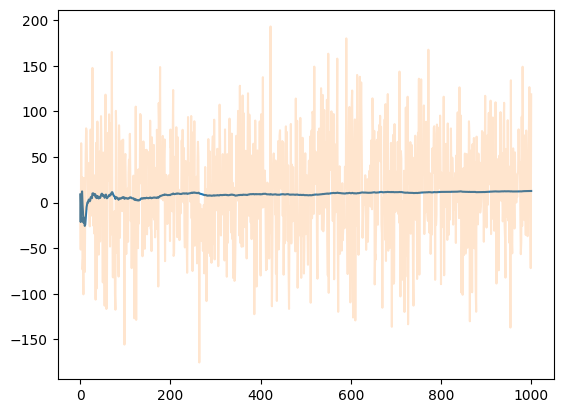

In [35]:
plt.plot(avg_lst)
plt.plot(forces, alpha=0.2)